<a href="https://colab.research.google.com/github/appgallery/Futsal-ML-Analysis/blob/main/New_Futsal_Player_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA

In [ ]:
# =============================================================================
# FUTSAL PLAYER DATA - EDA
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [ ]:
# =============================================================================
# LOAD DATA
# =============================================================================

events = pd.read_csv(
    "/content/players-futsal-men-scores.csv"
)

print("DATA SHAPE")
print(events.shape)

DATA SHAPE
(9890, 19)


In [ ]:
# =============================================================================
# BASIC INSPECTION
# =============================================================================

print("\nCOLUMNS")
print(events.columns)

print("\nDATA TYPES")
print(events.dtypes)

print("\nHEAD")
display(events.head())


COLUMNS
Index(['id', 'match_id', 'comp_id', 'team_id', 'user_id', 'assist_player_id',
       'type', 'is_self_goal', 'time', 'timer_type', 'half', 'match_time',
       'is_goal', 'is_reset', 'created_on', 'updated_on', 'first_name',
       'last_name', 'date_of_birth'],
      dtype='object')

DATA TYPES
id                    int64
match_id              int64
comp_id               int64
team_id               int64
user_id             float64
assist_player_id    float64
type                 object
is_self_goal          int64
time                 object
timer_type           object
half                  int64
match_time           object
is_goal             float64
is_reset              int64
created_on           object
updated_on           object
first_name           object
last_name            object
date_of_birth        object
dtype: object

HEAD


,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,433458,97881,430,17,401.0,NaN,SCORE,0,19:44,PLAY,1,19:44,1.0,0,1/20/2023 13:23,1/20/2023 13:23,Scott,Rogan,9/29/1998
1,433464,97881,430,331,2265.0,NaN,FOULS,0,10:01,PLAY,1,10:01,0.0,0,1/20/2023 13:34,1/20/2023 13:34,Anthony,Colosimo,7/11/1988
2,433465,97881,430,331,2265.0,NaN,FOULS,0,3:17,PLAY,1,3:17,0.0,0,1/20/2023 13:41,1/20/2023 13:41,Anthony,Colosimo,7/11/1988
3,433466,97881,430,331,1018.0,NaN,FOULS,0,2:44,PLAY,1,2:44,0.0,0,1/20/2023 13:42,1/20/2023 13:42,Nejdet,Sahin,10/28/1990
4,433467,97881,430,17,528.0,NaN,FOULS,0,1:55,PLAY,1,1:55,0.0,0,1/20/2023 13:42,1/20/2023 13:42,Michael,Nguyen,3/25/1999


In [ ]:
# =============================================================================
# MISSING VALUES
# =============================================================================

missing = (

    events.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (

    missing / len(events)
) * 100

missing_df = pd.DataFrame({

    'missing_count': missing,
    'missing_pct': missing_pct

})

print("\nMISSING VALUES")
display(missing_df)


MISSING VALUES


,missing_count,missing_pct
assist_player_id,8846,89.443883
time,1287,13.013145
match_time,1082,10.940344
is_goal,530,5.358948
first_name,444,4.489383
date_of_birth,444,4.489383
last_name,444,4.489383
user_id,6,0.060667
comp_id,0,0.000000
id,0,0.000000


In [ ]:
# =============================================================================
# DUPLICATES
# =============================================================================

duplicates = events.duplicated().sum()

print("\nDUPLICATES:", duplicates)


DUPLICATES: 0



EVENT TYPE COUNTS


,count
type,
FOULS,4558
SCORE,3634
YELLOWCARD,938
POSTMATCHTIME,308
PENALTY,205
REDCARD,92
FULLTIME,70
EXTRAHALFTIME,44
MEDICALCARD,25


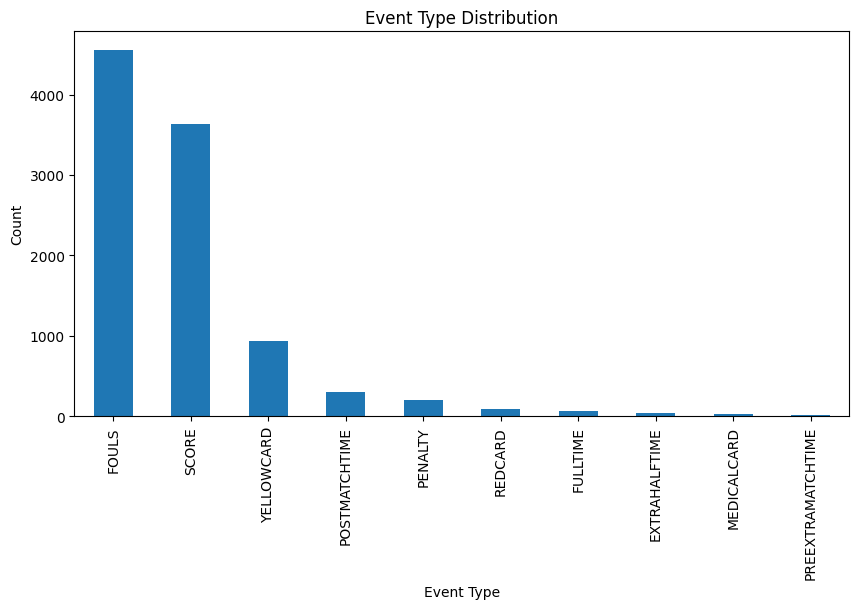

In [ ]:
# =============================================================================
# EVENT TYPE DISTRIBUTION
# =============================================================================

print("\nEVENT TYPE COUNTS")

event_counts = (
    events['type']
    .astype(str)
    .str.upper()
    .value_counts()
)

display(event_counts)

# PLOT
plt.figure(figsize=(10,5))

event_counts.plot(kind='bar')

plt.title("Event Type Distribution")

plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

In [ ]:
# =============================================================================
# UNIQUE PLAYERS
# =============================================================================

unique_players = events['user_id'].nunique()

print("\nUNIQUE PLAYERS:", unique_players)


UNIQUE PLAYERS: 395


In [ ]:
# =============================================================================
# UNIQUE MATCHES
# =============================================================================

unique_matches = events['match_id'].nunique()

print("UNIQUE MATCHES:", unique_matches)

UNIQUE MATCHES: 422


In [ ]:
# =============================================================================
# EVENTS PER MATCH
# =============================================================================

events_per_match = (

    events.groupby('match_id')
    .size()
)

print("\nEVENTS PER MATCH")

display(events_per_match.describe())


EVENTS PER MATCH


,0
count,422.000000
mean,23.436019
std,6.924735
min,3.000000
25%,19.000000
50%,23.000000
75%,27.000000
max,47.000000


In [ ]:
# =============================================================================
# EVENTS PER PLAYER
# =============================================================================

events_per_player = (

    events.groupby('user_id')
    .size()
)

print("\nEVENTS PER PLAYER")

display(events_per_player.describe())


EVENTS PER PLAYER


,0
count,395.000000
mean,25.022785
std,43.289276
min,1.000000
25%,3.000000
50%,9.000000
75%,28.000000
max,438.000000


In [ ]:
# =============================================================================
# GOAL ANALYSIS
# =============================================================================

events['type'] = (
    events['type']
    .astype(str)
    .str.upper()
)

events['goal'] = np.where(
    events['type'] == 'SCORE',
    1,
    0
)

goal_events = events['goal'].sum()

print("\nTOTAL GOALS:", goal_events)


TOTAL GOALS: 3634


In [ ]:
# =============================================================================
# TOP SCORERS
# =============================================================================

top_scorers = (

    events.groupby(
        ['user_id', 'first_name', 'last_name']
    )['goal']

    .sum()

    .sort_values(ascending=False)

    .head(20)
)

print("\nTOP SCORERS")

display(top_scorers)


TOP SCORERS


,,,goal
user_id,first_name,last_name,
429.0,Cosimo,Russo,187
384.0,Elias,Parthimos,143
401.0,Scott,Rogan,115
514.0,Henrique,Pimenta,97
715.0,Adam,Cooper,90
1190.0,Harry,Robotis,82
1724.0,Josh,Allen,76
1714.0,Behrad,Behzadpour,68
473.0,Andre,Caro Salve,67


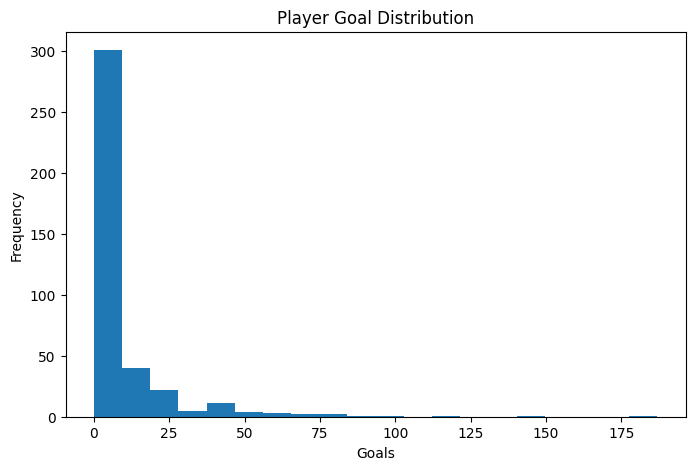

In [ ]:
# =============================================================================
# GOALS DISTRIBUTION
# =============================================================================

player_goals = (

    events.groupby('user_id')['goal']
    .sum()
)

plt.figure(figsize=(8,5))

plt.hist(
    player_goals,
    bins=20
)

plt.title("Player Goal Distribution")

plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# =============================================================================
# ASSIST ANALYSIS
# =============================================================================

events['assist'] = np.where(
    events['assist_player_id'].notnull(),
    1,
    0
)

print("\nTOTAL ASSISTS:")
print(events['assist'].sum())


TOTAL ASSISTS:
1044


In [ ]:
# =============================================================================
# FOUL ANALYSIS
# =============================================================================

events['foul'] = np.where(
    events['type'] == 'FOULS',
    1,
    0
)

print("\nTOTAL FOULS:")
print(events['foul'].sum())


TOTAL FOULS:
4558



AGE SUMMARY


,age
count,9416.000000
mean,26.279433
std,6.635676
min,-0.139630
25%,22.082820
50%,25.930185
75%,30.576318
max,45.431896


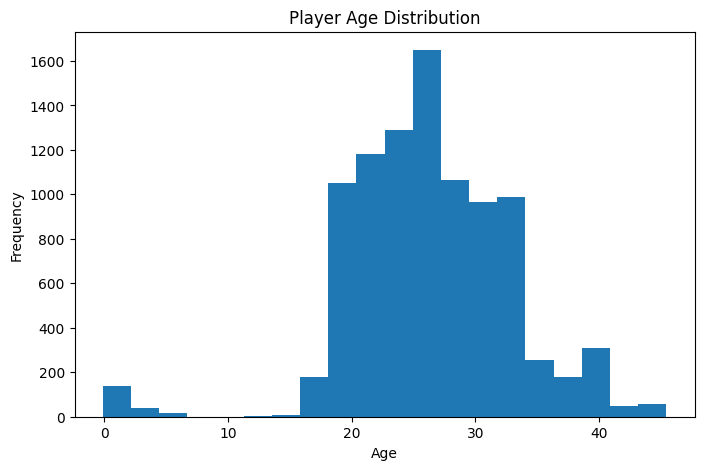

In [ ]:
# =============================================================================
# AGE ANALYSIS
# =============================================================================

if 'date_of_birth' in events.columns:

    events['date_of_birth'] = pd.to_datetime(
        events['date_of_birth'],
        errors='coerce'
    )

    events['created_on'] = pd.to_datetime(
        events['created_on'],
        errors='coerce'
    )

    events['age'] = (

        (
            events['created_on']
            -
            events['date_of_birth']
        )

        .dt.days / 365.25
    )

    print("\nAGE SUMMARY")

    display(
        events['age'].describe()
    )

    plt.figure(figsize=(8,5))

    plt.hist(
        events['age'].dropna(),
        bins=20
    )

    plt.title("Player Age Distribution")

    plt.xlabel("Age")

    plt.ylabel("Frequency")

    plt.show()

In [ ]:
# =============================================================================
# TEMPORAL COVERAGE
# =============================================================================

events['created_on'] = pd.to_datetime(
    events['created_on'],
    errors='coerce'
)

print("\nDATE RANGE")

print(
    events['created_on'].min(),
    " → ",
    events['created_on'].max()
)


DATE RANGE
2023-01-20 13:23:00  →  2026-04-27 09:33:00


In [ ]:
# =============================================================================
# PLAYER ACTIVITY DISTRIBUTION
# =============================================================================

matches_per_player = (

    events.groupby('user_id')['match_id']
    .nunique()
)

print("\nMATCHES PER PLAYER")

display(
    matches_per_player.describe()
)


MATCHES PER PLAYER


,match_id
count,395.000000
mean,11.969620
std,18.332216
min,1.000000
25%,2.000000
50%,5.000000
75%,15.000000
max,184.000000


In [ ]:
# =============================================================================
# LOW DATA PLAYERS
# =============================================================================

low_data_players = (
    matches_per_player < 3
).sum()

print("\nPLAYERS WITH <3 MATCHES:")
print(low_data_players)



PLAYERS WITH <3 MATCHES:
137


In [ ]:
# # =============================================================================
# # DATA QUALITY SUMMARY
# # =============================================================================

# print("\nEDA SUMMARY")
# print("-----------")

# print(f"Rows                 : {len(events)}")
# print(f"Matches              : {unique_matches}")
# print(f"Players              : {unique_players}")
# print(f"Goals                : {goal_events}")
# print(f"Assists              : {events['assist'].sum()}")
# print(f"Fouls                : {events['foul'].sum()}")
# print(f"Clutch Goals         : {events['clutch_goal'].sum()}")
# print(f"Duplicate Rows       : {duplicates}")
# print(f"Players <3 Matches   : {low_data_players}")

# Feature Engineering

In [ ]:
# =============================================================================
# FUTSAL PLAYER FEATURE ENGINEERING PIPELINE
# BUILT USING EDA INSIGHTS
# =============================================================================

# =============================================================================
# WHY THIS PIPELINE IS DIFFERENT
# =============================================================================
#
# This pipeline is based on actual EDA findings:
#
# 1. GOALS are heavily skewed
#    → use rolling averages instead of raw totals
#
# 2. Many players have very few matches
#    → remove low-history players
#
# 3. match_time is stored as MM:SS
#    → proper conversion required
#
# 4. Fouls are extremely common
#    → discipline features are important
#
# 5. Dataset is temporal (2023-2026)
#    → time-safe rolling features required
#
# 6. Event types are:
#    SCORE, FOULS, YELLOWCARD, REDCARD, PENALTY
#
# =============================================================================

In [ ]:
# =============================================================================
# LOAD DATA
# =============================================================================

MATCH_PATH = "/content/series-futsal-men-matches.csv"
EVENT_PATH = "/content/players-futsal-men-scores.csv"

In [ ]:
matches_raw = pd.read_csv(MATCH_PATH)
events_raw = pd.read_csv(EVENT_PATH)

print("MATCH DATA:", matches_raw.shape)
print("EVENT DATA:", events_raw.shape)

# =============================================================================
# CREATE COPIES
# =============================================================================

matches = matches_raw.copy()
events = events_raw.copy()

MATCH DATA: (423, 34)
EVENT DATA: (9890, 19)


In [ ]:
# REMOVE INVALID PLAYER ROWS
events = events.dropna(
    subset=['user_id', 'match_id']
)

In [ ]:
# REMOVE DUPLICATES
events = events.drop_duplicates()

In [ ]:
# STANDARDIZE EVENT TYPES
events['type'] = (

    events['type']
    .astype(str)
    .str.upper()
    .str.strip()

)

In [ ]:
# DATETIME CONVERSION
events['created_on'] = pd.to_datetime(
    events['created_on'],
    errors='coerce'
)

In [ ]:
# PLAYER NAME
events['player_name'] = (

    events['first_name'].fillna('') +
    ' ' +
    events['last_name'].fillna('')

).str.strip()

print("\nEVENT DATA CLEANED")
print(events.shape)


EVENT DATA CLEANED
(9884, 20)


In [ ]:
# Must convert to minutes
def convert_match_time(x):

    try:

        mins, secs = str(x).split(':')

        return int(mins) + (int(secs) / 60)

    except:

        return np.nan


events['match_time_mins'] = (

    events['match_time']
    .apply(convert_match_time)

)

print("\nMATCH TIME CONVERTED")


MATCH TIME CONVERTED


In [ ]:
# GOALS
events['goal'] = np.where(
    events['type'] == 'SCORE',
    1,
    0
)

# FOULS
events['foul'] = np.where(
    events['type'] == 'FOULS',
    1,
    0
)

# YELLOW CARDS
events['yellow_card'] = np.where(
    events['type'] == 'YELLOWCARD',
    1,
    0
)

# RED CARDS
events['red_card'] = np.where(
    events['type'] == 'REDCARD',
    1,
    0
)

# PENALTY EVENTS
events['penalty_event'] = np.where(
    events['type'] == 'PENALTY',
    1,
    0
)

# ASSISTS
events['assist'] = np.where(
    events['assist_player_id'].notnull(),
    1,
    0
)

# OWN GOALS
events['own_goal'] = np.where(
    events['is_self_goal'] == 1,
    1,
    0
)

print("\nEVENT FEATURES CREATED")


EVENT FEATURES CREATED


In [ ]:
# =============================================================================
# CLUTCH GOALS
# =============================================================================
#
# FUTSAL:
# late goals are high-impact
#
# =============================================================================

events['clutch_goal'] = np.where(

    (events['goal'] == 1) &
    (events['match_time_mins'] >= 15),

    1,
    0
)

print("\nCLUTCH GOALS CREATED")


CLUTCH GOALS CREATED


### Joining with match dataset for prediction of best performing player for winning team

In [ ]:
# CREATING LINK WITH PLAYER-MATCH DATASET
player_match = (
    events.groupby(
        [
            'match_id',
            'team_id',
            'user_id',
            'player_name'
        ]
    )

    .agg(

        goals=('goal', 'sum'),

        assists=('assist', 'sum'),

        fouls=('foul', 'sum'),

        yellow_cards=('yellow_card', 'sum'),

        red_cards=('red_card', 'sum'),

        penalties=('penalty_event', 'sum'),

        own_goals=('own_goal', 'sum'),

        clutch_goals=('clutch_goal', 'sum'),

        total_events=('type', 'count'),

        first_event_time=('created_on', 'min')

    )

    .reset_index()

)

print("\nPLAYER MATCH DATASET CREATED")
print(player_match.shape)


PLAYER MATCH DATASET CREATED
(4728, 14)


In [ ]:
# =============================================================================
# CLEAN MATCH DATA
# =============================================================================

match_cols = [

    'match_id',
    'startDate',
    'homeTeamId',
    'awayTeamId',
    'winningTeam',
    'winningTeamGoals',
    'losingTeamGoals'

]

match_cols = [

    c for c in match_cols
    if c in matches.columns

]

matches = matches[match_cols].copy()

matches['startDate'] = pd.to_datetime(
    matches['startDate'],
    errors='coerce'
)

matches = matches.drop_duplicates(
    subset=['match_id']
)

print("\nMATCH DATA CLEANED")


MATCH DATA CLEANED


In [ ]:
# =============================================================================
# JOIN MATCH INFORMATION
# =============================================================================

player_match = player_match.merge(

    matches,

    on='match_id',

    how='left'
)

print("\nMATCH DATA JOINED")
print(player_match.shape)


MATCH DATA JOINED
(4728, 20)


In [ ]:
# =============================================================================
# CREATE MATCH DATE
# =============================================================================

player_match['match_date'] = pd.to_datetime(
    player_match['startDate'],
    errors='coerce'
)

player_match = player_match.dropna(
    subset=['match_date']
)

In [ ]:
# =============================================================================
# REMOVE LOW HISTORY PLAYERS
# =============================================================================
#
# EDA INSIGHT:
# 137 players have <3 matches
#
# These players create unstable rolling features
#
# =============================================================================

matches_per_player = (

    player_match
    .groupby('user_id')['match_id']
    .nunique()

)

VALID_PLAYERS = matches_per_player[
    matches_per_player >= 3
].index

player_match = player_match[
    player_match['user_id'].isin(VALID_PLAYERS)
]

print("\nLOW HISTORY PLAYERS REMOVED")
print(player_match.shape)


LOW HISTORY PLAYERS REMOVED
(4552, 21)


In [ ]:
# =============================================================================
# CREATE TEAM RESULT FEATURE
# =============================================================================

player_match['player_team_won'] = np.where(

    player_match['team_id'] ==
    player_match['winningTeam'],

    1,
    0
)

In [ ]:
# =============================================================================
# PERFORMANCE SCORE
# =============================================================================
#
# BUILT FROM EDA INSIGHTS
#
# Goals:
# most valuable offensive action
#
# Fouls:
# extremely common in dataset
#
# Red cards:
# severe negative impact
#
# =============================================================================

player_match['perf_score'] = (

    player_match['goals'] * 3.0 +

    player_match['assists'] * 2.0 +

    player_match['clutch_goals'] * 1.5 +

    player_match['penalties'] * 1.0 +

    player_match['player_team_won'] * 1.5 -

    player_match['fouls'] * 0.5 -

    player_match['yellow_cards'] * 1.0 -

    player_match['red_cards'] * 3.0 -

    player_match['own_goals'] * 2.0
)

print("\nPERFORMANCE SCORE CREATED")


PERFORMANCE SCORE CREATED


In [ ]:
# =============================================================================
# BEST PLAYER LABEL
# =============================================================================

player_match['best_match_score'] = (

    player_match
    .groupby('match_id')['perf_score']
    .transform('max')
)

player_match['is_best_player'] = np.where(

    player_match['perf_score'] ==
    player_match['best_match_score'],

    1,
    0
)

print("\nBEST PLAYER LABEL CREATED")


BEST PLAYER LABEL CREATED


In [ ]:
# =============================================================================
# SORT FOR TIME-SAFE FEATURES
# =============================================================================

player_match = player_match.sort_values(
    ['user_id', 'match_date']
)

print("\nTIME SORTED")


TIME SORTED


In [ ]:
# =============================================================================
# ROLLING FEATURES
# =============================================================================
#
# EDA INSIGHT:
# goals heavily skewed
#
# rolling averages better than raw totals
#
# =============================================================================

WINDOW = 5


# -----------------------------------------------------------------------------
# RECENT GOAL FORM
# -----------------------------------------------------------------------------

player_match['roll5_goals'] = (

    player_match

    .groupby('user_id')['goals']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             WINDOW,
             min_periods=1
         )

         .mean()
    )
)

In [ ]:
# -----------------------------------------------------------------------------
# RECENT ASSIST FORM
# -----------------------------------------------------------------------------

player_match['roll5_assists'] = (

    player_match

    .groupby('user_id')['assists']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             WINDOW,
             min_periods=1
         )

         .mean()
    )
)

In [ ]:
# -----------------------------------------------------------------------------
# RECENT PERFORMANCE FORM
# -----------------------------------------------------------------------------

player_match['roll5_perf_score'] = (

    player_match

    .groupby('user_id')['perf_score']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             WINDOW,
             min_periods=1
         )

         .mean()
    )
)

In [ ]:
# -----------------------------------------------------------------------------
# RECENT DISCIPLINE FORM
# -----------------------------------------------------------------------------

player_match['roll5_fouls'] = (

    player_match

    .groupby('user_id')['fouls']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             WINDOW,
             min_periods=1
         )

         .mean()
    )
)

print("\nROLLING FEATURES CREATED")


ROLLING FEATURES CREATED


In [ ]:
# =============================================================================
# CAREER FEATURES
# =============================================================================
#
# Long-term player quality
#
# =============================================================================

player_match['career_matches'] = (

    player_match
    .groupby('user_id')
    .cumcount()
)

# CAREER GOALS BEFORE CURRENT MATCH
player_match['career_goals'] = (

    player_match

    .groupby('user_id')['goals']

    .cumsum()

    -

    player_match['goals']
)

# CAREER ASSISTS BEFORE CURRENT MATCH
player_match['career_assists'] = (

    player_match

    .groupby('user_id')['assists']

    .cumsum()

    -

    player_match['assists']
)

# CAREER PERFORMANCE BEFORE CURRENT MATCH
player_match['career_perf_score'] = (

    player_match

    .groupby('user_id')['perf_score']

    .cumsum()

    -

    player_match['perf_score']
)


In [ ]:
# =============================================================================
# SAFE CAREER AVERAGES
# =============================================================================

player_match['career_gpg'] = np.where(

    player_match['career_matches'] > 0,

    player_match['career_goals'] /
    player_match['career_matches'],

    0
)

player_match['career_apg'] = np.where(

    player_match['career_matches'] > 0,

    player_match['career_assists'] /
    player_match['career_matches'],

    0
)

player_match['career_avg_perf'] = np.where(

    player_match['career_matches'] > 0,

    player_match['career_perf_score'] /
    player_match['career_matches'],

    0
)

print("\nCAREER FEATURES CREATED")


CAREER FEATURES CREATED


In [ ]:
# =============================================================================
# MOMENTUM FEATURES
# =============================================================================
#
# Measures:
# Is player improving recently?
#
# =============================================================================

player_match['goal_trend'] = (

    player_match['roll5_goals']

    -

    player_match['career_gpg']
)

player_match['perf_trend'] = (

    player_match['roll5_perf_score']

    -

    player_match['career_avg_perf']
)

print("\nMOMENTUM FEATURES CREATED")


MOMENTUM FEATURES CREATED


In [ ]:
# =============================================================================
# AGE FEATURES
# =============================================================================

dob = (

    events[
        ['user_id', 'date_of_birth']
    ]

    .drop_duplicates('user_id')
)

dob['date_of_birth'] = pd.to_datetime(
    dob['date_of_birth'],
    errors='coerce'
)

player_match = player_match.merge(

    dob,

    on='user_id',

    how='left'
)

player_match['age'] = (

    (
        player_match['match_date']
        -
        player_match['date_of_birth']
    )

    .dt.days / 365.25
)

print("\nAGE FEATURES CREATED")


AGE FEATURES CREATED


In [ ]:
# =============================================================================
#
# EDA INSIGHT:
# Goal distribution highly skewed
#
# Log transforms stabilize heavy tails
#
# =============================================================================

player_match['log_career_goals'] = np.log1p(
    player_match['career_goals']
)

player_match['log_career_matches'] = np.log1p(
    player_match['career_matches']
)

print("\nLOG FEATURES CREATED")


LOG FEATURES CREATED


In [ ]:
# =============================================================================
# FINAL CLEANING
# =============================================================================

player_match = player_match.fillna(0)

print("\nFINAL DATASET SHAPE")
print(player_match.shape)


# =============================================================================
# FINAL FEATURE SUMMARY
# =============================================================================

feature_cols = [

    c for c in player_match.columns

    if c not in [

        'match_id',
        'player_name',
        'match_date',
        'startDate',
        'first_event_time'
    ]
]

print("\nTOTAL FEATURES:", len(feature_cols))

print("\nFEATURE LIST")
print(feature_cols)


# =============================================================================
# PREVIEW FINAL DATASET
# =============================================================================

display(

    player_match.head(20)

)





FINAL DATASET SHAPE
(4552, 42)

TOTAL FEATURES: 37

FEATURE LIST
['team_id', 'user_id', 'goals', 'assists', 'fouls', 'yellow_cards', 'red_cards', 'penalties', 'own_goals', 'clutch_goals', 'total_events', 'homeTeamId', 'awayTeamId', 'winningTeam', 'winningTeamGoals', 'losingTeamGoals', 'player_team_won', 'perf_score', 'best_match_score', 'is_best_player', 'roll5_goals', 'roll5_assists', 'roll5_perf_score', 'roll5_fouls', 'career_matches', 'career_goals', 'career_assists', 'career_perf_score', 'career_gpg', 'career_apg', 'career_avg_perf', 'goal_trend', 'perf_trend', 'date_of_birth', 'age', 'log_career_goals', 'log_career_matches']


,match_id,team_id,user_id,player_name,goals,assists,fouls,yellow_cards,red_cards,penalties,own_goals,clutch_goals,total_events,first_event_time,startDate,homeTeamId,awayTeamId,winningTeam,winningTeamGoals,losingTeamGoals,match_date,player_team_won,perf_score,best_match_score,is_best_player,roll5_goals,roll5_assists,roll5_perf_score,roll5_fouls,career_matches,career_goals,career_assists,career_perf_score,career_gpg,career_apg,career_avg_perf,goal_trend,perf_trend,date_of_birth,age,log_career_goals,log_career_matches
0,97882,0,0.0,,0,0,0,0,0,0,0,0,2,2023-01-20 15:47:00,2023-01-20,21,19,21,6,5,2023-01-20,0,0.0,11.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.000000
1,97903,0,0.0,,0,0,0,0,0,0,0,0,2,2023-02-24 16:53:00,2023-02-24,20,325,325,3,2,2023-02-24,0,0.0,5.5,0,0.0,0.0,0.0,0.0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.693147
2,97908,0,0.0,,0,0,0,0,0,0,0,0,2,2023-03-03 18:17:00,2023-03-03,21,22,21,5,4,2023-03-03,0,0.0,7.0,0,0.0,0.0,0.0,0.0,2,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.098612
3,97909,0,0.0,,0,0,0,0,0,0,0,0,2,2023-03-10 14:23:00,2023-03-10,331,17,331,2,1,2023-03-10,0,0.0,5.5,0,0.0,0.0,0.0,0.0,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.386294
4,97911,0,0.0,,0,0,0,0,0,0,0,0,3,2023-03-10 16:56:00,2023-03-10,22,20,20,4,3,2023-03-10,0,0.0,8.5,0,0.0,0.0,0.0,0.0,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.609438
5,97912,0,0.0,,0,0,0,0,0,0,0,0,3,2023-03-10 18:18:00,2023-03-10,21,19,19,5,4,2023-03-10,0,0.0,8.5,0,0.0,0.0,0.0,0.0,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.791759
6,97922,0,0.0,,0,0,0,0,0,0,0,0,2,2023-03-31 15:40:00,2023-03-31,19,22,22,4,3,2023-03-31,0,0.0,8.5,0,0.0,0.0,0.0,0.0,6,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.945910
7,97931,0,0.0,,0,0,0,0,0,0,0,0,8,2023-04-21 19:06:00,2023-04-21,17,19,17,16,2,2023-04-21,0,0.0,15.0,0,0.0,0.0,0.0,0.0,7,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,2.079442
8,97946,0,0.0,,0,0,0,0,0,0,0,0,2,2023-05-19 18:03:00,2023-05-19,20,331,20,4,3,2023-05-19,0,0.0,12.0,0,0.0,0.0,0.0,0.0,8,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,2.197225
9,97949,0,0.0,,0,0,0,0,0,0,0,0,1,2023-05-26 18:03:00,2023-05-26,21,20,20,5,4,2023-05-26,0,0.0,11.5,0,0.0,0.0,0.0,0.0,9,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,2.302585


In [ ]:
# =============================================================================
# SAVE FINAL FEATURE DATASET
# =============================================================================

player_match.to_csv(
    "player_match_features.csv",
    index=False
)

print("\nFEATURE ENGINEERING COMPLETE")
print("Saved: player_match_features.csv")


FEATURE ENGINEERING COMPLETE
Saved: player_match_features.csv


In [ ]:

# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np


# =============================================================================
# LOAD FEATURE DATASET
# =============================================================================

df = pd.read_csv("player_match_features.csv")

print("ORIGINAL SHAPE")
print(df.shape)


# =============================================================================
# BASIC INSPECTION
# =============================================================================

print("\nCHECKING INVALID IDs")

print("\nINVALID user_id")
print((df['user_id'] == 0).sum())

print("\nINVALID team_id")
print((df['team_id'] == 0).sum())

print("\nMISSING user_id")
print(df['user_id'].isnull().sum())

print("\nMISSING team_id")
print(df['team_id'].isnull().sum())


# =============================================================================
# REMOVE INVALID PLAYERS
# =============================================================================

df = df[
    df['user_id'].notnull()
]

df = df[
    df['team_id'].notnull()
]

df = df[
    df['user_id'] != 0
]

df = df[
    df['team_id'] != 0
]

print("\nAFTER INVALID ROW REMOVAL")
print(df.shape)


# =============================================================================
# REMOVE EMPTY PLAYER NAMES
# =============================================================================

df['player_name'] = (
    df['player_name']
    .astype(str)
)

df = df[
    df['player_name'].str.strip() != ''
]

df = df[
    df['player_name'].str.lower() != 'nan'
]

print("\nAFTER PLAYER NAME CLEANING")
print(df.shape)


# =============================================================================
# CHECK DUPLICATES
# =============================================================================

duplicates = df.duplicated().sum()

print("\nDUPLICATES:", duplicates)

if duplicates > 0:

    df = df.drop_duplicates()

    print("DUPLICATES REMOVED")


# =============================================================================
# VERIFY ASSIST DISTRIBUTION
# =============================================================================

print("\nASSIST DISTRIBUTION")

print(

    df['assists']
    .describe()

)

# OPTIONAL:
# REMOVE EXTREME ASSIST OUTLIERS

ASSIST_CAP = 6

df['assists'] = np.where(

    df['assists'] > ASSIST_CAP,

    ASSIST_CAP,

    df['assists']
)

print("\nASSISTS CAPPED")


# =============================================================================
# VERIFY GOAL DISTRIBUTION
# =============================================================================

print("\nGOAL DISTRIBUTION")

print(

    df['goals']
    .describe()

)


# =============================================================================
# REMOVE EXTREME OUTLIERS (OPTIONAL)
# =============================================================================
#
# Prevent rare unrealistic rows
#
# =============================================================================

MAX_GOALS = 10

df = df[
    df['goals'] <= MAX_GOALS
]

print("\nAFTER GOAL OUTLIER FILTER")
print(df.shape)


# =============================================================================
# CHECK CLUTCH GOALS
# =============================================================================

print("\nCLUTCH GOALS SUMMARY")

print(

    df['clutch_goals']
    .describe()

)


# =============================================================================
# FIX NaNs SAFELY
# =============================================================================
#
# IMPORTANT:
# Only numeric columns
#
# NEVER:
# IDs
# names
# dates
#
# =============================================================================

numeric_cols = df.select_dtypes(
    include=[np.number]
).columns

df[numeric_cols] = (

    df[numeric_cols]
    .fillna(0)

)

print("\nNUMERIC NaNs FIXED")


# =============================================================================
# VERIFY NO INVALID IDs REMAIN
# =============================================================================

print("\nFINAL VALIDATION")

print("INVALID user_id:",
      (df['user_id'] == 0).sum())

print("INVALID team_id:",
      (df['team_id'] == 0).sum())

print("MISSING player_name:",
      df['player_name'].isnull().sum())


# =============================================================================
# CHECK PERFORMANCE SCORE
# =============================================================================

print("\nPERFORMANCE SCORE SUMMARY")

print(

    df['perf_score']
    .describe()

)


# =============================================================================
# CHECK BEST PLAYER LABEL BALANCE
# =============================================================================

print("\nBEST PLAYER LABEL DISTRIBUTION")

print(

    df['is_best_player']
    .value_counts()

)


# =============================================================================
# FINAL CHRONOLOGICAL SORT
# =============================================================================

df['match_date'] = pd.to_datetime(
    df['match_date'],
    errors='coerce'
)

df = df.sort_values(
    ['match_date', 'user_id']
)

print("\nFINAL SORT COMPLETE")


# =============================================================================
# FINAL DATASET INFO
# =============================================================================

print("\nFINAL DATASET SHAPE")
print(df.shape)

print("\nFINAL COLUMN COUNT")
print(len(df.columns))


# =============================================================================
# PREVIEW CLEAN DATASET
# =============================================================================

display(

    df.head(20)

)


# =============================================================================
# SAVE CLEAN DATASET
# =============================================================================

OUTPUT_FILE = "player_match_features_clean.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nCLEAN DATASET SAVED")
print(OUTPUT_FILE)

ORIGINAL SHAPE
(4552, 42)

CHECKING INVALID IDs

INVALID user_id
184

INVALID team_id
184

MISSING user_id
0

MISSING team_id
0

AFTER INVALID ROW REMOVAL
(4368, 42)

AFTER PLAYER NAME CLEANING
(4368, 42)

DUPLICATES: 0

ASSIST DISTRIBUTION
count    4368.000000
mean        0.209249
std         0.702436
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        10.000000
Name: assists, dtype: float64

ASSISTS CAPPED

GOAL DISTRIBUTION
count    4368.000000
mean        0.812500
std         0.968881
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         8.000000
Name: goals, dtype: float64

AFTER GOAL OUTLIER FILTER
(4368, 42)

CLUTCH GOALS SUMMARY
count    4368.000000
mean        0.177885
std         0.436167
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: clutch_goals, dtype: float64

NUMERIC NaNs FIXED

FINAL VALIDATION
INVALID user_id: 0
INVALID te

,match_id,team_id,user_id,player_name,goals,assists,fouls,yellow_cards,red_cards,penalties,own_goals,clutch_goals,total_events,first_event_time,startDate,homeTeamId,awayTeamId,winningTeam,winningTeamGoals,losingTeamGoals,match_date,player_team_won,perf_score,best_match_score,is_best_player,roll5_goals,roll5_assists,roll5_perf_score,roll5_fouls,career_matches,career_goals,career_assists,career_perf_score,career_gpg,career_apg,career_avg_perf,goal_trend,perf_trend,date_of_birth,age,log_career_goals,log_career_matches
211,97881,17,384.0,Elias Parthimos,1,0,1,0,0,0,0,0,2,2023-01-20 13:53:00,2023-01-20,331,17,17,5,1,2023-01-20,1,4.0,13.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,2003-08-20 00:00:00,19.419576,0.0,0.0
307,97883,325,391.0,Stephen Gustus,0,0,3,1,0,0,0,0,4,2023-05-07 12:58:00,2023-01-20,325,18,18,4,1,2023-01-20,0,-2.5,7.5,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1994-08-04 00:00:00,28.462697,0.0,0.0
337,97881,17,401.0,Scott Rogan,3,0,1,0,0,0,0,2,4,2023-01-20 13:23:00,2023-01-20,331,17,17,5,1,2023-01-20,1,13.0,13.0,1,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1998-09-29 00:00:00,24.309377,0.0,0.0
523,97881,17,429.0,Cosimo Russo,1,0,1,1,0,0,0,1,3,2023-01-20 13:58:00,2023-01-20,331,17,17,5,1,2023-01-20,1,4.5,13.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1998-03-08 00:00:00,24.870637,0.0,0.0
622,97882,21,435.0,Daniel Chaabani,0,0,2,0,0,1,0,0,3,2023-01-20 14:44:00,2023-01-20,21,19,21,6,5,2023-01-20,1,1.5,11.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-21 00:00:00,2.997947,0.0,0.0
647,97882,19,439.0,Michael Lettini,3,0,0,0,0,1,1,0,4,2023-01-20 14:52:00,2023-01-20,21,19,21,6,5,2023-01-20,0,8.0,11.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1992-02-29 00:00:00,30.891170,0.0,0.0
787,97881,17,455.0,Jorge Arturo Garzon Diaz,0,0,1,0,0,0,0,0,1,2023-01-20 14:04:00,2023-01-20,331,17,17,5,1,2023-01-20,1,1.0,13.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1993-03-27 00:00:00,29.817933,0.0,0.0
835,97882,21,458.0,Ubeyde Cicek,2,0,1,0,0,1,0,2,4,2023-01-20 14:40:00,2023-01-20,21,19,21,6,5,2023-01-20,1,11.0,11.0,1,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1995-11-26 00:00:00,27.151266,0.0,0.0
916,97882,21,469.0,Joao Da Silva,2,0,0,0,0,0,0,0,2,2023-01-20 15:02:00,2023-01-20,21,19,21,6,5,2023-01-20,1,7.5,11.0,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1982-01-20 00:00:00,40.999316,0.0,0.0
1046,97883,18,496.0,Alisson Lima da Rosa,0,0,1,0,0,0,0,0,1,2023-05-07 12:58:00,2023-01-20,325,18,18,4,1,2023-01-20,1,1.0,7.5,0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1992-07-09 00:00:00,30.532512,0.0,0.0



CLEAN DATASET SAVED
player_match_features_clean.csv


In [ ]:
# =============================================================================
# FUTSAL PLAYER PERFORMANCE ML PIPELINE
# =============================================================================
#
# GOAL:
# Predict future player performance
#
# MODEL TYPE:
# Regression
#
# TARGET:
# perf_score
#
# PIPELINE:
# 1. Load clean dataset
# 2. Time-safe split
# 3. GridSearchCV
# 4. Train multiple models
# 5. Select best model
# 6. Evaluate
# 7. Feature importance
# 8. Inference pipeline
# 9. Predict unknown/new player data
#
# =============================================================================


# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# LOAD DATASET
# =============================================================================

DATA_PATH = "player_match_features_clean.csv"

df = pd.read_csv(DATA_PATH)

print("DATASET SHAPE")
print(df.shape)


# =============================================================================
# DATE CONVERSION
# =============================================================================

df['match_date'] = pd.to_datetime(
    df['match_date'],
    errors='coerce'
)

# SORT CHRONOLOGICALLY
df = df.sort_values('match_date')


# =============================================================================
# REMOVE LEAKAGE FEATURES
# =============================================================================

REMOVE_COLS = [

    # IDs
    'match_id',
    'user_id',
    'player_name',

    # TARGETS
    'perf_score',
    'best_match_score',
    'is_best_player',

    # FUTURE INFORMATION
    'winningTeam',
    'winningTeamGoals',
    'losingTeamGoals',

    # DATES
    'match_date',
    'startDate',
    'first_event_time',
    'date_of_birth'
]

FEATURES = [

    c for c in df.columns

    if c not in REMOVE_COLS
]

TARGET = 'perf_score'

print("\nTOTAL FEATURES:", len(FEATURES))


# =============================================================================
# BUILD FEATURE MATRICES
# =============================================================================

X = df[FEATURES]
y = df[TARGET]


# =============================================================================
# TIME SAFE TRAIN TEST SPLIT
# =============================================================================
#
# IMPORTANT:
# Never random split sports temporal data
#
# =============================================================================

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTRAIN SHAPE")
print(X_train.shape)

print("\nTEST SHAPE")
print(X_test.shape)


# =============================================================================
# EVALUATION FUNCTION
# =============================================================================

def evaluate_regression_model(model, X_test, y_test):

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    r2 = r2_score(y_test, preds)

    return {

        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    }


# =============================================================================
# MODEL TRAINING FUNCTION
# =============================================================================

def train_model_gridsearch(
    model,
    param_grid,
    X_train,
    y_train,
    model_name
):

    print("\n" + "="*80)
    print(f"TRAINING {model_name}")
    print("="*80)

    grid = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        scoring='neg_mean_squared_error',

        cv=3,

        verbose=1,

        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\nBEST PARAMETERS")
    print(grid.best_params_)

    print("\nBEST SCORE")
    print(grid.best_score_)

    return grid.best_estimator_


# =============================================================================
# RANDOM FOREST
# =============================================================================

rf_model = RandomForestRegressor(
    random_state=42
)

rf_params = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

best_rf = train_model_gridsearch(

    rf_model,
    rf_params,
    X_train,
    y_train,
    "RANDOM FOREST"
)

rf_results = evaluate_regression_model(
    best_rf,
    X_test,
    y_test
)

print("\nRANDOM FOREST RESULTS")
print(rf_results)


# =============================================================================
# GRADIENT BOOSTING
# =============================================================================

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_params = {

    'n_estimators': [100, 200],

    'learning_rate': [0.05, 0.1],

    'max_depth': [3, 5]
}

best_gb = train_model_gridsearch(

    gb_model,
    gb_params,
    X_train,
    y_train,
    "GRADIENT BOOSTING"
)

gb_results = evaluate_regression_model(
    best_gb,
    X_test,
    y_test
)

print("\nGRADIENT BOOSTING RESULTS")
print(gb_results)


# =============================================================================
# XGBOOST
# =============================================================================

xgb_model = XGBRegressor(
    random_state=42
)

xgb_params = {

    'n_estimators': [200, 300],

    'max_depth': [4, 6],

    'learning_rate': [0.03, 0.05],

    'subsample': [0.8],

    'colsample_bytree': [0.8]
}

best_xgb = train_model_gridsearch(

    xgb_model,
    xgb_params,
    X_train,
    y_train,
    "XGBOOST"
)

xgb_results = evaluate_regression_model(
    best_xgb,
    X_test,
    y_test
)

print("\nXGBOOST RESULTS")
print(xgb_results)


# =============================================================================
# MODEL COMPARISON
# =============================================================================

results_df = pd.DataFrame({

    'Model': [

        'RandomForest',
        'GradientBoosting',
        'XGBoost'
    ],

    'MAE': [

        rf_results['MAE'],
        gb_results['MAE'],
        xgb_results['MAE']
    ],

    'RMSE': [

        rf_results['RMSE'],
        gb_results['RMSE'],
        xgb_results['RMSE']
    ],

    'R2': [

        rf_results['R2'],
        gb_results['R2'],
        xgb_results['R2']
    ]
})

print("\nMODEL COMPARISON")
display(results_df)


# =============================================================================
# SELECT BEST MODEL
# =============================================================================

best_model = best_xgb

print("\nBEST MODEL SELECTED: XGBOOST")


# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

importance_df = pd.DataFrame({

    'feature': FEATURES,

    'importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print("\nTOP FEATURE IMPORTANCE")

display(
    importance_df.head(20)
)


# =============================================================================
# TEST PREDICTIONS
# =============================================================================

test_preds = best_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df['actual_perf_score'] = y_test.values

prediction_df['predicted_perf_score'] = test_preds

prediction_df['prediction_error'] = (

    prediction_df['actual_perf_score']
    -
    prediction_df['predicted_perf_score']
)

print("\nTEST PREDICTIONS")

display(
    prediction_df[
        [
            'actual_perf_score',
            'predicted_perf_score',
            'prediction_error'
        ]
    ].head(20)
)


# =============================================================================
# PLAYER RANKING
# =============================================================================

test_players = df.iloc[X_test.index][
    ['player_name']
].copy()

test_players['predicted_perf_score'] = test_preds

top_players = test_players.sort_values(

    'predicted_perf_score',
    ascending=False
)

print("\nTOP PREDICTED PLAYERS")

display(
    top_players.head(20)
)


# =============================================================================
# INFERENCE FUNCTION
# =============================================================================
#
# Predict future performance
#
# =============================================================================

def predict_player_performance(
    model,
    input_df,
    feature_columns
):

    predictions = model.predict(
        input_df[feature_columns]
    )

    output = input_df.copy()

    output['predicted_perf_score'] = predictions

    output = output.sort_values(
        'predicted_perf_score',
        ascending=False
    )

    return output


# =============================================================================
# UNKNOWN / NEW DATA EXAMPLE
# =============================================================================
#
# Simulating future match player features
#
# =============================================================================

new_player_data = pd.DataFrame({

    'team_id': [430, 430, 430],

    'goals': [0, 0, 0],

    'assists': [0, 0, 0],

    'fouls': [1, 0, 2],

    'yellow_cards': [0, 0, 1],

    'red_cards': [0, 0, 0],

    'penalties': [0, 1, 0],

    'own_goals': [0, 0, 0],

    'clutch_goals': [0, 0, 0],

    'total_events': [5, 7, 4],

    'homeTeamId': [17, 17, 17],

    'awayTeamId': [33, 33, 33],

    'player_team_won': [1, 1, 1],

    'roll5_goals': [1.2, 0.5, 0.1],

    'roll5_assists': [0.4, 0.2, 0.1],

    'roll5_perf_score': [5.2, 3.1, 1.4],

    'roll5_fouls': [0.6, 0.3, 1.5],

    'career_matches': [45, 20, 10],

    'career_goals': [38, 12, 3],

    'career_assists': [11, 5, 1],

    'career_perf_score': [190, 72, 20],

    'career_gpg': [0.84, 0.60, 0.30],

    'career_apg': [0.24, 0.25, 0.10],

    'career_avg_perf': [4.2, 3.6, 2.0],

    'goal_trend': [0.36, -0.10, -0.20],

    'perf_trend': [1.0, 0.2, -0.5],

    'age': [27, 24, 33],

    'log_career_goals': np.log1p([38, 12, 3]),

    'log_career_matches': np.log1p([45, 20, 10])

})

print("\nNEW PLAYER DATA")
display(new_player_data)


# =============================================================================
# RUN INFERENCE
# =============================================================================

future_predictions = predict_player_performance(

    best_model,

    new_player_data,

    FEATURES
)

print("\nFUTURE PLAYER PERFORMANCE PREDICTIONS")

display(
    future_predictions[
        ['predicted_perf_score']
    ]
)


# =============================================================================
# BEST PLAYER PREDICTION
# =============================================================================

best_future_player = future_predictions.iloc[0]

print("\nPREDICTED BEST PLAYER")

print(best_future_player)

DATASET SHAPE
(4368, 42)

TOTAL FEATURES: 29

TRAIN SHAPE
(3494, 29)

TEST SHAPE
(874, 29)

TRAINING RANDOM FOREST
Fitting 3 folds for each of 24 candidates, totalling 72 fits

BEST PARAMETERS
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

BEST SCORE
-0.17331561518790892

RANDOM FOREST RESULTS
{'MAE': 2.1171, 'RMSE': np.float64(3.2353), 'R2': 0.5265}

TRAINING GRADIENT BOOSTING
Fitting 3 folds for each of 8 candidates, totalling 24 fits

BEST PARAMETERS
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

BEST SCORE
-0.03948483791969446

GRADIENT BOOSTING RESULTS
{'MAE': 2.1153, 'RMSE': np.float64(3.2824), 'R2': 0.5126}

TRAINING XGBOOST
Fitting 3 folds for each of 8 candidates, totalling 24 fits

BEST PARAMETERS
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

BEST SCORE
-0.0487399083625993

XGBOOST RESULTS
{'MAE': 2.1137, 'RMSE': np.float64(3.2778), 'R2': 0.514}

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,RandomForest,2.1171,3.2353,0.5265
1,GradientBoosting,2.1153,3.2824,0.5126
2,XGBoost,2.1137,3.2778,0.5140



BEST MODEL SELECTED: XGBOOST

TOP FEATURE IMPORTANCE


,feature,importance
1,goals,0.504867
12,player_team_won,0.146123
8,clutch_goals,0.138191
4,yellow_cards,0.049486
9,total_events,0.041322
5,red_cards,0.034675
3,fouls,0.033188
21,career_gpg,0.016732
7,own_goals,0.016724
6,penalties,0.008943



TEST PREDICTIONS


...


NEW PLAYER DATA


,team_id,goals,assists,fouls,yellow_cards,red_cards,penalties,own_goals,clutch_goals,total_events,homeTeamId,awayTeamId,player_team_won,roll5_goals,roll5_assists,roll5_perf_score,roll5_fouls,career_matches,career_goals,career_assists,career_perf_score,career_gpg,career_apg,career_avg_perf,goal_trend,perf_trend,age,log_career_goals,log_career_matches
0,430,0,0,1,0,0,0,0,0,5,17,33,1,1.2,0.4,5.2,0.6,45,38,11,190,0.84,0.24,4.2,0.36,1.0,27,3.663562,3.828641
1,430,0,0,0,0,0,1,0,0,7,17,33,1,0.5,0.2,3.1,0.3,20,12,5,72,0.60,0.25,3.6,-0.10,0.2,24,2.564949,3.044522
2,430,0,0,2,1,0,0,0,0,4,17,33,1,0.1,0.1,1.4,1.5,10,3,1,20,0.30,0.10,2.0,-0.20,-0.5,33,1.386294,2.397895



FUTURE PLAYER PERFORMANCE PREDICTIONS


,predicted_perf_score
1,1.892277
0,0.465965
2,-0.795091



PREDICTED BEST PLAYER
team_id                 430.000000
goals                     0.000000
assists                   0.000000
fouls                     0.000000
yellow_cards              0.000000
red_cards                 0.000000
penalties                 1.000000
own_goals                 0.000000
clutch_goals              0.000000
total_events              7.000000
homeTeamId               17.000000
awayTeamId               33.000000
player_team_won           1.000000
roll5_goals               0.500000
roll5_assists             0.200000
roll5_perf_score          3.100000
roll5_fouls               0.300000
career_matches           20.000000
career_goals             12.000000
career_assists            5.000000
career_perf_score        72.000000
career_gpg                0.600000
career_apg                0.250000
career_avg_perf           3.600000
goal_trend               -0.100000
perf_trend                0.200000
age                      24.000000
log_career_goals          2.5649

In [ ]:
# =============================================================================
# FINAL CORRECTED PLAYER PERFORMANCE PREDICTION SYSTEM
# =============================================================================
#
# FIXES:
#
# 1. Removed team IDs
# 2. Removed probability softmax issue
# 3. Proper probability normalization
# 4. Leakage-free prediction
# 5. Multiple models
# 6. Best model selection
#
# =============================================================================


# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# LOAD DATASET
# =============================================================================

df = pd.read_csv(
    "player_match_features_clean.csv"
)

print("DATASET SHAPE")
print(df.shape)


# =============================================================================
# DATE PROCESSING
# =============================================================================

df['match_date'] = pd.to_datetime(
    df['match_date'],
    errors='coerce'
)

df = df.sort_values('match_date')


# =============================================================================
# FINAL SAFE FEATURES
# =============================================================================
#
# IMPORTANT:
# Removed:
# - team_id
# - homeTeamId
# - awayTeamId
#
# =============================================================================

FEATURES = [

    'roll5_goals',
    'roll5_assists',
    'roll5_perf_score',
    'roll5_fouls',

    'career_matches',
    'career_goals',
    'career_assists',
    'career_perf_score',

    'career_gpg',
    'career_apg',
    'career_avg_perf',

    'goal_trend',
    'perf_trend',

    'age',

    'log_career_goals',
    'log_career_matches'
]

TARGET = 'perf_score'

print("\nFINAL FEATURES")
print(FEATURES)

print("\nTOTAL FEATURES")
print(len(FEATURES))


# =============================================================================
# BUILD MATRICES
# =============================================================================

X = df[FEATURES]
y = df[TARGET]


# =============================================================================
# TIME SAFE SPLIT
# =============================================================================

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTRAIN SHAPE")
print(X_train.shape)

print("\nTEST SHAPE")
print(X_test.shape)


# =============================================================================
# EVALUATION FUNCTION
# =============================================================================

def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    r2 = r2_score(y_test, preds)

    return {

        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    }


# =============================================================================
# TRAINING FUNCTION
# =============================================================================

def train_gridsearch_model(

    model,
    param_grid,
    model_name,
    X_train,
    y_train
):

    print("\n" + "="*80)
    print(f"TRAINING {model_name}")
    print("="*80)

    grid = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        scoring='neg_mean_squared_error',

        cv=3,

        verbose=1,

        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    print("\nBEST PARAMETERS")
    print(grid.best_params_)

    results = evaluate_model(
        best_model,
        X_test,
        y_test
    )

    print("\nRESULTS")
    print(results)

    return {

        'model_name': model_name,

        'best_model': best_model,

        'results': results
    }


# =============================================================================
# MODEL STORAGE
# =============================================================================

models = []


# =============================================================================
# RANDOM FOREST
# =============================================================================

rf_model = RandomForestRegressor(
    random_state=42
)

rf_params = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 10],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

models.append(

    train_gridsearch_model(

        rf_model,
        rf_params,
        "RandomForest",
        X_train,
        y_train
    )
)


# =============================================================================
# GRADIENT BOOSTING
# =============================================================================

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_params = {

    'n_estimators': [100, 200],

    'learning_rate': [0.03, 0.05, 0.1],

    'max_depth': [3, 5]
}

models.append(

    train_gridsearch_model(

        gb_model,
        gb_params,
        "GradientBoosting",
        X_train,
        y_train
    )
)


# =============================================================================
# EXTRA TREES
# =============================================================================

et_model = ExtraTreesRegressor(
    random_state=42
)

et_params = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10],

    'min_samples_split': [2, 5]
}

models.append(

    train_gridsearch_model(

        et_model,
        et_params,
        "ExtraTrees",
        X_train,
        y_train
    )
)


# =============================================================================
# RIDGE REGRESSION
# =============================================================================

ridge_model = Ridge()

ridge_params = {

    'alpha': [0.1, 1.0, 10.0]
}

models.append(

    train_gridsearch_model(

        ridge_model,
        ridge_params,
        "RidgeRegression",
        X_train,
        y_train
    )
)


# =============================================================================
# XGBOOST
# =============================================================================

xgb_model = XGBRegressor(
    random_state=42
)

xgb_params = {

    'n_estimators': [100, 200],

    'max_depth': [3, 4, 5],

    'learning_rate': [0.03, 0.05],

    'subsample': [0.8],

    'colsample_bytree': [0.8]
}

models.append(

    train_gridsearch_model(

        xgb_model,
        xgb_params,
        "XGBoost",
        X_train,
        y_train
    )
)


# =============================================================================
# MODEL COMPARISON
# =============================================================================

comparison_rows = []

for m in models:

    row = {

        'Model': m['model_name'],

        'MAE': m['results']['MAE'],

        'RMSE': m['results']['RMSE'],

        'R2': m['results']['R2']
    }

    comparison_rows.append(row)

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df = comparison_df.sort_values(

    'R2',
    ascending=False
)

print("\nMODEL COMPARISON")
display(comparison_df)


# =============================================================================
# SELECT BEST MODEL
# =============================================================================

BEST_MODEL_NAME = comparison_df.iloc[0]['Model']

print("\nBEST MODEL")
print(BEST_MODEL_NAME)

best_model = None

for m in models:

    if m['model_name'] == BEST_MODEL_NAME:

        best_model = m['best_model']


# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

if hasattr(best_model, 'feature_importances_'):

    importance_df = pd.DataFrame({

        'feature': FEATURES,

        'importance': best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(

        'importance',
        ascending=False
    )

    print("\nTOP FEATURES")

    display(
        importance_df.head(20)
    )


# =============================================================================
# CORRECT PROBABILITY FUNCTION
# =============================================================================
#
# FIXED:
# No exponential softmax
#
# =============================================================================

def convert_scores_to_probabilities(scores):

    scores = np.array(scores)

    # REMOVE NEGATIVE VALUES
    scores = scores - scores.min()

    # PREVENT ZERO DIVISION
    scores = scores + 1

    probs = scores / scores.sum()

    return probs * 100


# =============================================================================
# PLAYER PREDICTION FUNCTION
# =============================================================================

def predict_player_match_performance(

    model,
    player_df,
    feature_cols
):

    preds = model.predict(
        player_df[feature_cols]
    )

    result = player_df.copy()

    result['predicted_perf_score'] = preds

    result['play_well_probability'] = (

        convert_scores_to_probabilities(preds)
    )

    result['play_well_probability'] = (

        result['play_well_probability']
        .round(2)
    )

    result = result.sort_values(

        'play_well_probability',
        ascending=False
    )

    return result


# =============================================================================
# FUTURE MATCH EXAMPLE
# =============================================================================

HOME_TEAM = "Melbourne AKU FC"
AWAY_TEAM = "Moreland Blues FC"

home_win_probability = 67
away_win_probability = 33


# =============================================================================
# FUTURE PLAYER FEATURES
# =============================================================================

future_players = pd.DataFrame({

    'roll5_goals': [1.4, 1.0, 0.9],

    'roll5_assists': [0.5, 0.3, 0.2],

    'roll5_perf_score': [6.2, 5.4, 4.1],

    'roll5_fouls': [0.4, 0.5, 1.1],

    'career_matches': [80, 65, 55],

    'career_goals': [95, 71, 49],

    'career_assists': [32, 21, 14],

    'career_perf_score': [420, 310, 220],

    'career_gpg': [1.18, 1.09, 0.89],

    'career_apg': [0.40, 0.32, 0.25],

    'career_avg_perf': [5.3, 4.8, 4.0],

    'goal_trend': [0.22, 0.10, -0.08],

    'perf_trend': [1.2, 0.7, -0.3],

    'age': [27, 29, 31],

    'log_career_goals': np.log1p([95, 71, 49]),

    'log_career_matches': np.log1p([80, 65, 55])

})

future_players['player_name'] = [

    'Scott Rogan',
    'Elias Parthimos',
    'Michael Nguyen'
]

future_players['team_name'] = [

    'Melbourne AKU FC',
    'Melbourne AKU FC',
    'Moreland Blues FC'
]


# =============================================================================
# RUN PREDICTIONS
# =============================================================================

player_predictions = predict_player_match_performance(

    best_model,

    future_players,

    FEATURES
)


# =============================================================================
# FINAL MATCH REPORT
# =============================================================================

final_report = player_predictions[
    [
        'team_name',
        'player_name',
        'play_well_probability'
    ]
].copy()

final_report['win_probability'] = np.where(

    final_report['team_name'] == HOME_TEAM,

    home_win_probability,

    away_win_probability
)

final_report = final_report[
    [
        'team_name',
        'win_probability',
        'player_name',
        'play_well_probability'
    ]
]

final_report = final_report.sort_values(

    ['win_probability', 'play_well_probability'],

    ascending=False
)

print("\nFINAL MATCH REPORT")
print("="*80)

display(final_report)


# =============================================================================
# SAVE REPORT
# =============================================================================

# final_report.to_csv(

#     "future_match_prediction_report.csv",

#     index=False
# )

# print("\nREPORT SAVED")
# print("future_match_prediction_report.csv")

DATASET SHAPE
(4368, 42)

FINAL FEATURES
['roll5_goals', 'roll5_assists', 'roll5_perf_score', 'roll5_fouls', 'career_matches', 'career_goals', 'career_assists', 'career_perf_score', 'career_gpg', 'career_apg', 'career_avg_perf', 'goal_trend', 'perf_trend', 'age', 'log_career_goals', 'log_career_matches']

TOTAL FEATURES
16

TRAIN SHAPE
(3494, 16)

TEST SHAPE
(874, 16)

TRAINING RandomForest
Fitting 3 folds for each of 24 candidates, totalling 72 fits

BEST PARAMETERS
{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

RESULTS
{'MAE': 3.3724, 'RMSE': np.float64(4.7852), 'R2': -0.0359}

TRAINING GradientBoosting
Fitting 3 folds for each of 12 candidates, totalling 36 fits

BEST PARAMETERS
{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}

RESULTS
{'MAE': 3.4047, 'RMSE': np.float64(4.8393), 'R2': -0.0594}

TRAINING ExtraTrees
Fitting 3 folds for each of 8 candidates, totalling 24 fits

BEST PARAMETERS
{'max_depth': 5, 'min_samples_split': 5, 'n

,Model,MAE,RMSE,R2
2,ExtraTrees,3.3748,4.7849,-0.0357
0,RandomForest,3.3724,4.7852,-0.0359
3,RidgeRegression,3.3641,4.8022,-0.0432
4,XGBoost,3.4051,4.8379,-0.0588
1,GradientBoosting,3.4047,4.8393,-0.0594



BEST MODEL
ExtraTrees

TOP FEATURES


,feature,importance
10,career_avg_perf,0.321088
8,career_gpg,0.217327
2,roll5_perf_score,0.100830
0,roll5_goals,0.092658
7,career_perf_score,0.069221
14,log_career_goals,0.049828
5,career_goals,0.039775
15,log_career_matches,0.031616
11,goal_trend,0.019277
4,career_matches,0.016596



FINAL MATCH REPORT


,team_name,win_probability,player_name,play_well_probability
0,Melbourne AKU FC,67,Scott Rogan,40.27
1,Melbourne AKU FC,67,Elias Parthimos,39.82
2,Moreland Blues FC,33,Michael Nguyen,19.91
